In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir('C:\\Users\\ferna\\OneDrive\\Downloads\\GitHub\\ml_factorinv')

In [119]:
from data.data_load import *

### Compute size portfolios

In [120]:
df_median         = data_ml[['date', 'Mkt_Cap_12M_Usd']].groupby('date').median().reset_index()
df_median.columns = ['date', 'cap_median'] # empirical cdf not perfect, some values != 0.5
df_median

,date,cap_median
0,2000-01-31,0.50
1,2000-02-29,0.50
2,2000-03-31,0.50
3,2000-04-30,0.49
4,2000-05-31,0.49
...,...,...
223,2018-08-31,0.49
224,2018-09-30,0.49
225,2018-10-31,0.49
226,2018-11-30,0.49


In [121]:
df_temp = pd.merge(data_ml[["date",'Mkt_Cap_12M_Usd','R1M_Usd']], df_median, how='left', on=['date'])
df_temp

,date,Mkt_Cap_12M_Usd,R1M_Usd,cap_median
0,2006-12-31,0.24,0.089,0.50
1,2007-01-31,0.24,0.039,0.50
2,2007-02-28,0.25,-0.012,0.50
3,2015-03-31,0.33,0.174,0.50
4,2015-04-30,0.30,-0.106,0.50
...,...,...,...,...
268331,2004-05-31,0.97,-0.029,0.50
268332,2004-07-31,0.96,0.028,0.50
268333,2004-08-31,0.96,0.011,0.50
268334,2004-09-30,0.96,0.045,0.50


In [122]:
df_temp = df_temp.groupby([pd.to_datetime(df['date']).dt.year,
                           np.where(df_temp['Mkt_Cap_12M_Usd'] > df_temp['cap_median'], 'large', 'small')])['R1M_Usd'].mean().reset_index() 
df_temp.rename(columns = {'level_1': 'cap_sort'}, inplace = True) 
df_temp.head(5)

,date,cap_sort,R1M_Usd
0,2000,large,0.016128
1,2000,small,0.034563
2,2001,large,0.003807
3,2001,small,0.032586
4,2002,large,-0.012713


Text(0.5, 0, 'year')

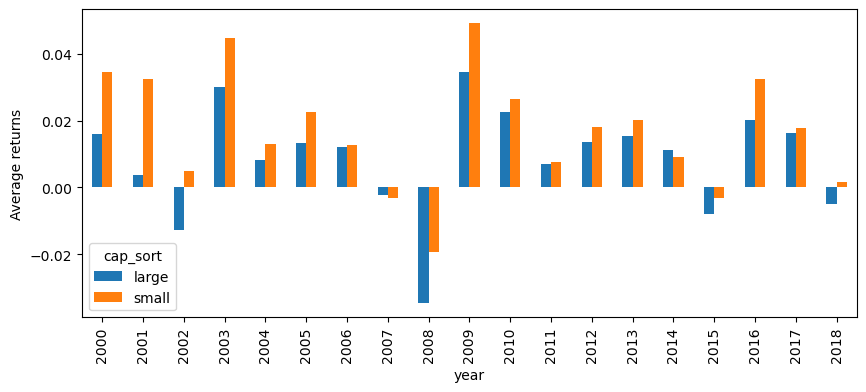

In [123]:
df_temp.pivot(index='date',columns='cap_sort',values='R1M_Usd').plot.bar(figsize=(10,4))
plt.ylabel('Average returns')
plt.xlabel('year')  

### Kenneth French dataset

In [124]:
import urllib.request
import zipfile

ff_url   = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip" 
urllib.request.urlretrieve(ff_url,'data/factors.zip') 

with zipfile.ZipFile("data/factors.zip", "r") as z: 
    z.extractall('data')

df_ff = pd.read_csv('data/F-F_Research_Data_5_Factors_2x3.csv', header=3, sep=',', quotechar='"').dropna()
df_ff.rename(columns = {'Mkt-RF':'MKT_RF'}, inplace = True) # renaming for clarity

In [125]:
df_ff.rename(columns = {'Unnamed: 0':'date'}, inplace = True)

In [126]:
idx_date = df_ff['date'].str.strip().str.len() == 6 # has year and yearmonnth dates in dataset; select yearmonth
df_ff = df_ff[idx_date]
df_ff['date'] = pd.to_datetime(df_ff['date'],format = '%Y%m')

In [127]:
cols = ['MKT_RF','SMB','HML','RMW','CMA','RF']
df_ff[cols] = df_ff[cols].apply(pd.to_numeric, errors = 'coerce')

In [128]:
min_date = '1963-07-31'
max_date = '2020-03-28'
df_ff[['MKT_RF','SMB','HML','RMW','CMA','RF']] = df_ff[['MKT_RF','SMB','HML','RMW','CMA','RF']]/100.0 # Scale returns
df_ff['year'] = pd.to_datetime(df_ff['date']).dt.year

In [129]:
idx_ff=df_ff.index[(df_ff['date'] >= min_date) & (df_ff['date'] <= max_date)].tolist()
FF_factors=df_ff.iloc[idx_ff]
FF_factors.head()

,date,MKT_RF,SMB,HML,RMW,CMA,RF,year
1,1963-08-01,0.0508,-0.0080,0.0172,0.0040,-0.0038,0.0025,1963
2,1963-09-01,-0.0157,-0.0043,-0.0002,-0.0078,0.0015,0.0027,1963
3,1963-10-01,0.0254,-0.0134,-0.0003,0.0279,-0.0225,0.0029,1963
4,1963-11-01,-0.0086,-0.0085,0.0178,-0.0043,0.0227,0.0027,1963
5,1963-12-01,0.0183,-0.0189,-0.0021,0.0012,-0.0025,0.0029,1963


Text(0.5, 0, 'date')

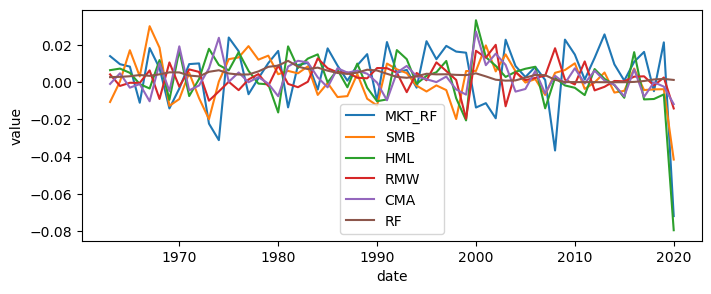

In [130]:
FF_factors.groupby(FF_factors['year']).mean().iloc[:,1:].plot(figsize = (8,3))
plt.ylabel('value')
plt.xlabel('date')

## Fama-Macbeth regressions

In [131]:
import statsmodels.api as sm

In [132]:
FF_factors_me = FF_factors.set_index('date').resample('ME').last().reset_index() # match 'ME' frequency; with returns

In [133]:
# Merge returns of data_ml(stock_id available on full sample) with factor features of Fama-Macbeth
data_FM = pd.merge(returns.reset_index(),FF_factors_me.iloc[:,0:7],how='left', on=['date']) 
data_FM.dropna(inplace=True)
data_FM

,date,1,3,4,7,9,11,12,16,17,...,1208,1209,1210,1212,MKT_RF,SMB,HML,RMW,CMA,RF
0,2000-01-31,-0.036,0.077,-0.016,-0.009,0.032,0.144,-0.110,-0.191,-0.103,...,-0.372,-0.560,-0.006,-0.186,-0.0474,0.0417,-0.0110,-0.0608,0.0448,0.0041
1,2000-02-29,0.263,-0.024,0.000,0.027,0.076,0.258,0.110,0.197,-0.053,...,0.143,-0.102,-0.057,0.104,0.0245,0.1854,-0.0973,-0.1893,-0.0106,0.0043
2,2000-03-31,0.031,0.018,0.153,0.000,-0.025,0.049,0.134,-0.030,0.074,...,0.057,0.144,0.085,-0.143,0.0521,-0.1553,0.0848,0.1162,-0.0120,0.0047
3,2000-04-30,0.448,0.027,-0.011,-0.017,-0.022,0.014,0.022,0.161,0.051,...,0.070,-0.103,0.073,0.204,-0.0635,-0.0479,0.0645,0.0806,0.0560,0.0046
4,2000-05-31,-0.097,0.050,0.014,0.018,-0.121,-0.116,-0.038,-0.020,0.038,...,-0.137,0.113,0.016,0.042,-0.0439,-0.0386,0.0458,0.0406,0.0145,0.0050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223,2018-08-31,-0.002,-0.049,0.036,-0.068,-0.028,0.146,0.040,0.016,0.297,...,0.126,-0.009,-0.011,0.044,0.0346,0.0067,-0.0393,-0.0034,-0.0254,0.0016
224,2018-09-30,-0.155,-0.070,-0.025,-0.052,-0.098,-0.291,-0.044,-0.050,-0.150,...,-0.119,0.000,0.028,-0.266,0.0006,-0.0249,-0.0168,0.0064,0.0137,0.0015
225,2018-10-31,0.014,0.036,0.000,0.007,-0.018,-0.100,0.074,0.094,-0.081,...,0.205,0.076,0.063,0.013,-0.0764,-0.0436,0.0343,0.0094,0.0356,0.0019
226,2018-11-30,-0.110,-0.070,-0.088,-0.066,-0.099,-0.251,-0.105,-0.059,-0.171,...,-0.189,-0.147,-0.064,-0.125,0.0171,-0.0081,0.0034,-0.0062,0.0039,0.0018


In [134]:
stocks_list = list(returns.columns) # stock_ids
len(stocks_list)

793

In [135]:
cols  = ['MKT_RF','SMB','HML','RMW','CMA','RF'] # factors used

#### Stage 1

In [136]:
results_params = []
reg_result     = []      
df_res_full    = pd.DataFrame()
for i in stocks_list:
    Y = data_FM.loc[:,i]
    results = sm.OLS(endog=Y,exog= sm.add_constant(data_FM.loc[:,cols])).fit()
    results_params = results.params
    reg_result=pd.DataFrame(results_params, columns = [i])
    df_res_full = pd.concat([df_res_full, reg_result],axis = 1)

In [137]:
df_res_full_t = df_res_full.transpose()
df_res_full_t

,const,MKT_RF,SMB,HML,RMW,CMA,RF
1,0.014771,0.437360,-0.333900,0.607682,-0.232657,0.252064,2.720235
3,0.008906,0.195482,-0.341687,0.672055,-0.439948,-0.304102,-0.846197
4,0.007992,-0.085199,-0.138435,0.223037,-0.071207,-0.517826,3.162695
7,0.015152,-0.200346,-0.181050,0.235984,-0.363297,-0.103355,-0.293320
9,0.011362,0.059476,0.000645,-0.197176,0.068656,0.644937,-0.169389
...,...,...,...,...,...,...,...
1204,0.013658,-0.215502,-0.125345,0.106174,-0.477620,-0.473666,0.708782
1208,0.029790,0.157758,-0.684967,0.564751,-0.264385,-0.753899,-5.433072
1209,0.015730,0.182622,-0.611570,0.013174,-0.076747,-0.511412,0.034608
1210,0.016066,-0.004213,-0.320474,0.346910,-0.426578,0.054681,-0.428192


In [138]:
returns.transpose()

date,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,2000-06-30,2000-07-31,2000-08-31,2000-09-30,2000-10-31,...,2018-03-31,2018-04-30,2018-05-31,2018-06-30,2018-07-31,2018-08-31,2018-09-30,2018-10-31,2018-11-30,2018-12-31
stock_id,,,,,,,,,,,,,,,,,,,,,
1,-0.036,0.263,0.031,0.448,-0.097,-0.157,0.291,0.037,-0.079,0.100,...,0.173,-0.042,-0.038,0.000,-0.077,-0.002,-0.155,0.014,-0.110,0.082
3,0.077,-0.024,0.018,0.027,0.050,0.008,-0.020,0.056,-0.039,-0.012,...,-0.039,0.030,-0.028,-0.039,0.033,-0.049,-0.070,0.036,-0.070,0.030
4,-0.016,0.000,0.153,-0.011,0.014,0.048,-0.005,0.020,0.044,0.049,...,0.071,-0.024,0.059,0.029,-0.004,0.036,-0.025,0.000,-0.088,0.043
7,-0.009,0.027,0.000,-0.017,0.018,0.061,-0.041,-0.016,-0.009,-0.035,...,0.030,0.100,0.036,-0.005,0.022,-0.068,-0.052,0.007,-0.066,0.131
9,0.032,0.076,-0.025,-0.022,-0.121,-0.030,0.072,0.017,-0.006,-0.025,...,0.046,0.047,0.000,0.064,-0.137,-0.028,-0.098,-0.018,-0.099,0.112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1204,0.080,0.161,-0.008,-0.114,-0.089,0.123,-0.041,-0.118,0.135,0.139,...,-0.038,-0.018,-0.036,0.061,0.046,0.005,-0.161,0.107,-0.050,0.147
1208,-0.372,0.143,0.057,0.070,-0.137,-0.071,-0.055,-0.193,-0.146,-0.549,...,-0.018,-0.130,0.014,0.011,-0.054,0.126,-0.119,0.205,-0.189,0.227
1209,-0.560,-0.102,0.144,-0.103,0.113,0.155,0.049,0.116,0.007,-0.108,...,-0.052,0.066,-0.020,0.016,0.142,-0.009,0.000,0.076,-0.147,0.092


#### Stage 2

In [139]:
df_fm2 = pd.concat([df_res_full_t, returns.transpose()], axis = 1)
df_fm2

,const,MKT_RF,SMB,HML,RMW,CMA,RF,2000-01-31 00:00:00,2000-02-29 00:00:00,2000-03-31 00:00:00,...,2018-03-31 00:00:00,2018-04-30 00:00:00,2018-05-31 00:00:00,2018-06-30 00:00:00,2018-07-31 00:00:00,2018-08-31 00:00:00,2018-09-30 00:00:00,2018-10-31 00:00:00,2018-11-30 00:00:00,2018-12-31 00:00:00
1,0.014771,0.437360,-0.333900,0.607682,-0.232657,0.252064,2.720235,-0.036,0.263,0.031,...,0.173,-0.042,-0.038,0.000,-0.077,-0.002,-0.155,0.014,-0.110,0.082
3,0.008906,0.195482,-0.341687,0.672055,-0.439948,-0.304102,-0.846197,0.077,-0.024,0.018,...,-0.039,0.030,-0.028,-0.039,0.033,-0.049,-0.070,0.036,-0.070,0.030
4,0.007992,-0.085199,-0.138435,0.223037,-0.071207,-0.517826,3.162695,-0.016,0.000,0.153,...,0.071,-0.024,0.059,0.029,-0.004,0.036,-0.025,0.000,-0.088,0.043
7,0.015152,-0.200346,-0.181050,0.235984,-0.363297,-0.103355,-0.293320,-0.009,0.027,0.000,...,0.030,0.100,0.036,-0.005,0.022,-0.068,-0.052,0.007,-0.066,0.131
9,0.011362,0.059476,0.000645,-0.197176,0.068656,0.644937,-0.169389,0.032,0.076,-0.025,...,0.046,0.047,0.000,0.064,-0.137,-0.028,-0.098,-0.018,-0.099,0.112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1204,0.013658,-0.215502,-0.125345,0.106174,-0.477620,-0.473666,0.708782,0.080,0.161,-0.008,...,-0.038,-0.018,-0.036,0.061,0.046,0.005,-0.161,0.107,-0.050,0.147
1208,0.029790,0.157758,-0.684967,0.564751,-0.264385,-0.753899,-5.433072,-0.372,0.143,0.057,...,-0.018,-0.130,0.014,0.011,-0.054,0.126,-0.119,0.205,-0.189,0.227
1209,0.015730,0.182622,-0.611570,0.013174,-0.076747,-0.511412,0.034608,-0.560,-0.102,0.144,...,-0.052,0.066,-0.020,0.016,0.142,-0.009,0.000,0.076,-0.147,0.092
1210,0.016066,-0.004213,-0.320474,0.346910,-0.426578,0.054681,-0.428192,-0.006,-0.057,0.085,...,0.020,0.063,0.051,-0.006,0.021,-0.011,0.028,0.063,-0.064,0.108


In [140]:
df_fm2.isna().isna().sum().sum() # no nan

np.int64(0)

In [141]:
cols_reg = df_fm2.columns[1:7] # do not include intercept of 1st stage
dates = df_fm2.columns[7:]

In [142]:
l_premia = []
for ii in dates:
    results = sm.OLS(endog = df_fm2.loc[:,ii],exog= sm.add_constant(df_fm2.loc[:,cols_reg])).fit()
    l_premia.append(results.params)

In [143]:
df_fm3 = pd.DataFrame(l_premia, index = dates) # dataframe of premia
df_fm3.head()

,const,MKT_RF,SMB,HML,RMW,CMA,RF
2000-01-31 00:00:00,-0.032299,-0.145016,-0.091400,0.019039,-0.143517,0.134338,0.001850
2000-02-29 00:00:00,0.067661,0.108361,0.214330,-0.067664,-0.190585,0.004915,0.001285
2000-03-31 00:00:00,-0.003263,-0.001092,-0.133420,0.107096,0.106098,-0.037862,0.001698
2000-04-30 00:00:00,0.007563,-0.289587,-0.241340,0.419370,0.427167,0.317622,0.023190
2000-05-31 00:00:00,-0.000891,-0.112362,-0.103675,0.058311,0.042612,0.033430,0.003348


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >], dtype=object)

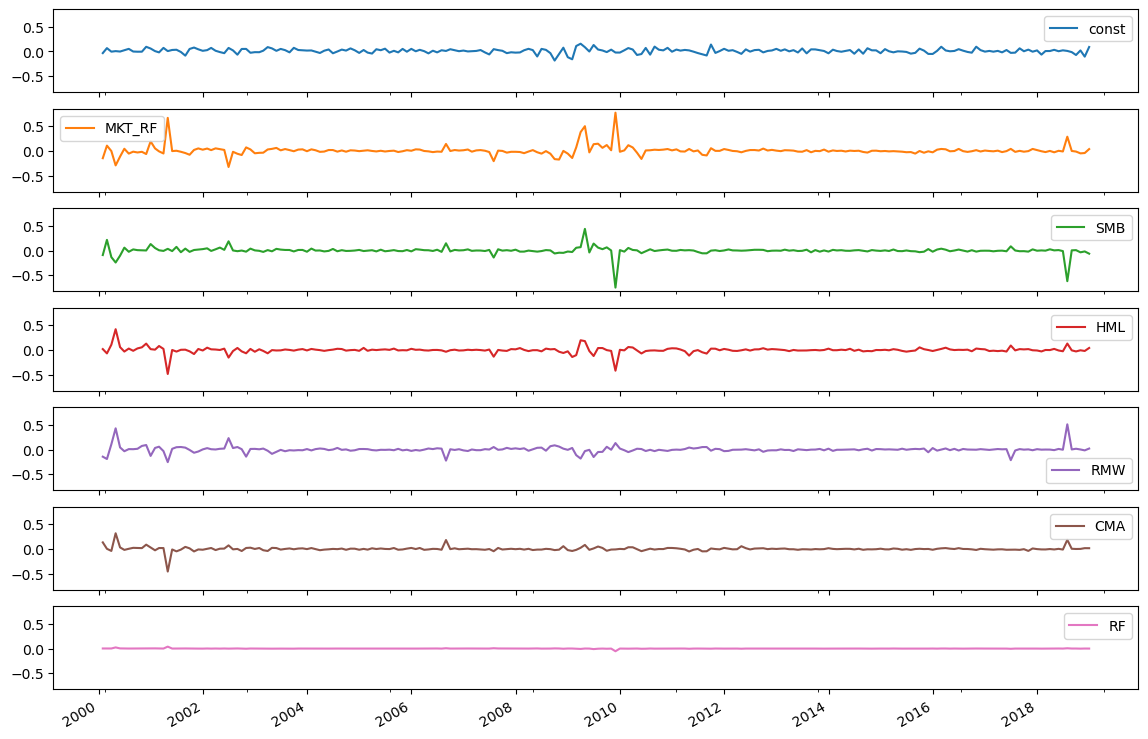

In [144]:
df_fm3.plot(figsize=(14,10), subplots=True, sharey=True, sharex=True)

### Factor Momentum
* serial correlation in 1st lag for RMW, CMA, HML.

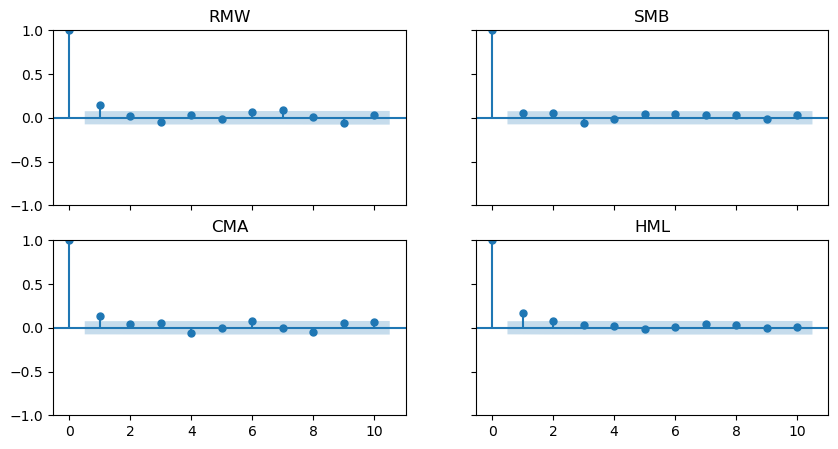

In [145]:
fig, ax = plt.subplots(2,2,figsize=(10,5),sharex='all', sharey='all') # how to
sm.graphics.tsa.plot_acf(FF_factors.RMW, lags=10, ax=ax[0,0],title='RMW') # check for the name 
sm.graphics.tsa.plot_acf(FF_factors.CMA, lags=10, ax=ax[1,0],title='CMA')
sm.graphics.tsa.plot_acf(FF_factors.SMB, lags=10, ax=ax[0,1],title='SMB')
sm.graphics.tsa.plot_acf(FF_factors.HML, lags=10, ax=ax[1,1],title='HML')
plt.show()

# Exercises

## Exercise 1 - Compute mean annual returns of the growth vs. value portfolios

In [146]:
df_median = data_ml[['date', 'Pb']].groupby('date').median().reset_index()
df_median.rename(columns = {'Pb':'Pb_median'}, inplace = True)
df_median.head(3)

,date,Pb_median
0,2000-01-31,0.5
1,2000-02-29,0.5
2,2000-03-31,0.5


In [147]:
df_temp = pd.merge(data_ml[["date",'Pb','R1M_Usd']], df_median, on = 'date', how = 'left')
df_temp.head(3)

,date,Pb,R1M_Usd,Pb_median
0,2006-12-31,0.5,0.089,0.5
1,2007-01-31,0.5,0.039,0.5
2,2007-02-28,0.5,-0.012,0.5


In [148]:
df_year = df_temp.groupby([pd.to_datetime(df_temp['date']).dt.year,
                         np.where(df_temp['Pb'] >= df_temp['Pb_median'],'Value', 'Growth')])['R1M_Usd'].mean().reset_index()
df_year.rename(columns = {'level_1': 'Pb_sort'},inplace = True)

In [149]:
df_year.head(4)

,date,Pb_sort,R1M_Usd
0,2000,Growth,0.032341
1,2000,Value,0.018777
2,2001,Growth,0.029568
3,2001,Value,0.007865


In [150]:
df_pbyear = pd.pivot(df_year,index = 'date', columns = 'Pb_sort', values = 'R1M_Usd')

<Axes: xlabel='date'>

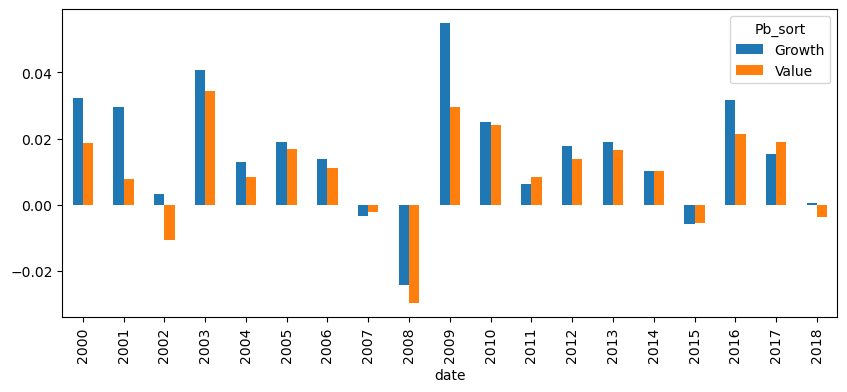

In [151]:
df_pbyear.plot.bar(figsize = (10,4))

## Exercise 2 - Same, but compute monthly returns

In [152]:
df_month = df_temp.groupby([df_temp['date'],
                         np.where(df_temp['Pb'] >= df_temp['Pb_median'],'Value', 'Growth')])['R1M_Usd'].mean().reset_index()
df_month.rename(columns = {'level_1': 'Pb_sort'},inplace = True)
df_month

,date,Pb_sort,R1M_Usd
0,2000-01-31,Growth,-0.019253
1,2000-01-31,Value,0.060093
2,2000-02-29,Growth,0.069378
3,2000-02-29,Value,0.059050
4,2000-03-31,Growth,0.032720
...,...,...,...
451,2018-10-31,Value,0.032228
452,2018-11-30,Growth,-0.107707
453,2018-11-30,Value,-0.106213
454,2018-12-31,Growth,0.123089


<Axes: xlabel='date'>

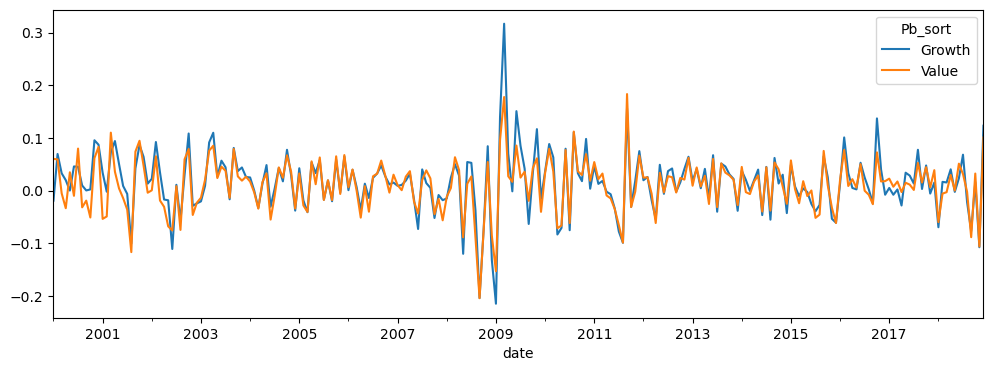

In [153]:
df_pbmonth = pd.pivot(df_month,index = 'date', columns = 'Pb_sort', values = 'R1M_Usd')
df_pbmonth.plot(figsize = (12,4))

<Axes: xlabel='date'>

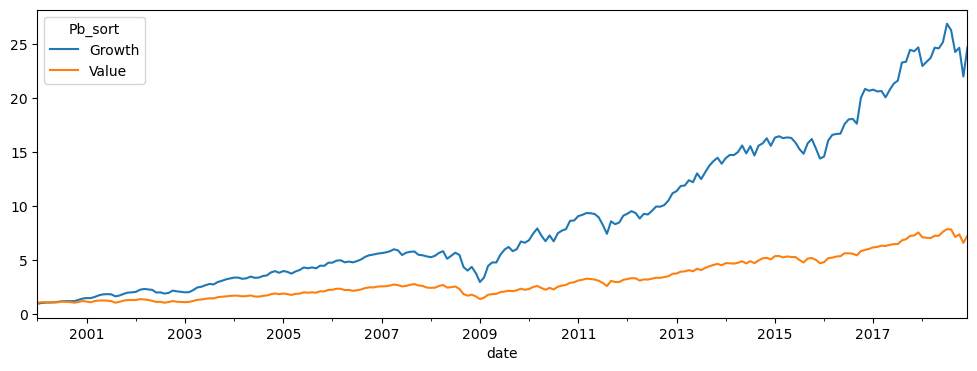

In [154]:
df_pbmonth_cum = (1 + df_pbmonth).cumprod()
df_pbmonth_cum.plot(figsize = (12,4))

## Exercise 3

Compute yearly quartiles of Pb portfolios and plot them

In [155]:
# unstack() for wide format
df_quartile = data_ml[['date', 'Pb']].groupby('date').quantile([0.25,0.5,0.75]).unstack().reset_index() 
df_quartile.rename(columns = {'level_1':'quartile','Pb':'Pb_q'}, inplace = True)
df_quartile.head(3)

date    Pb_q           
                0.25  0.5  0.75
0 2000-01-31  0.2425  0.5  0.74
1 2000-02-29  0.2425  0.5  0.74
2 2000-03-31  0.2500  0.5  0.73

In [156]:
df_quartile.columns

MultiIndex([('date',   ''),
            ('Pb_q', 0.25),
            ('Pb_q',  0.5),
            ('Pb_q', 0.75)],
           )

In [157]:
# Treating multindex in columns
df_quartile.columns = [
    '_'.join(str(c) for c in col if c != '') # string join with '_'
    for col in df_quartile.columns
]
df_quartile

,date,Pb_q_0.25,Pb_q_0.5,Pb_q_0.75
0,2000-01-31,0.2425,0.50,0.74
1,2000-02-29,0.2425,0.50,0.74
2,2000-03-31,0.2500,0.50,0.73
3,2000-04-30,0.2500,0.50,0.73
4,2000-05-31,0.2500,0.50,0.73
...,...,...,...,...
223,2018-08-31,0.2500,0.50,0.73
224,2018-09-30,0.2500,0.50,0.74
225,2018-10-31,0.2500,0.50,0.74
226,2018-11-30,0.2500,0.50,0.74


In [158]:
df_temp = pd.merge(data_ml[["date",'Pb','R1M_Usd']], df_quartile, on = 'date', how = 'left')
df_temp

,date,Pb,R1M_Usd,Pb_q_0.25,Pb_q_0.5,Pb_q_0.75
0,2006-12-31,0.50,0.089,0.25,0.5,0.7300
1,2007-01-31,0.50,0.039,0.25,0.5,0.7300
2,2007-02-28,0.50,-0.012,0.25,0.5,0.7300
3,2015-03-31,0.50,0.174,0.25,0.5,0.7300
4,2015-04-30,0.50,-0.106,0.25,0.5,0.7300
...,...,...,...,...,...,...
268331,2004-05-31,0.27,-0.029,0.26,0.5,0.7375
268332,2004-07-31,0.17,0.028,0.26,0.5,0.7400
268333,2004-08-31,0.17,0.011,0.26,0.5,0.7400
268334,2004-09-30,0.15,0.045,0.26,0.5,0.7300


In [159]:
# Nested conditionals, less clear
df_quartile = (
    df_temp
    .groupby([
        pd.to_datetime(df_temp['date']).dt.year,
        np.where(
            df_temp['Pb'] <= df_temp['Pb_q_0.25'], 'small',
            np.where(
                (df_temp['Pb'] > df_temp['Pb_q_0.25']) & (df_temp['Pb'] <= df_temp['Pb_q_0.5']), 'medium',
                np.where(
                    (df_temp['Pb'] > df_temp['Pb_q_0.5']) & (df_temp['Pb'] <= df_temp['Pb_q_0.75']), 'large',
                    'xl'
                )
            )
        )
    ])['R1M_Usd']
    .mean()
    .reset_index()
)

df_quartile.columns = ['year', 'Pb_group', 'R1M_Usd']


In [160]:
df_quartile

,year,Pb_group,R1M_Usd
0,2000,large,0.027432
1,2000,medium,0.025403
2,2000,small,0.041824
3,2000,xl,0.007024
4,2001,large,0.012258
...,...,...,...
71,2017,xl,0.020930
72,2018,large,-0.004703
73,2018,medium,-0.002653
74,2018,small,0.003936


In [161]:
# Other way with cut; but inputs quantiles from normalized dist.instead of empirical. 
df_temp['year'] = pd.to_datetime(df_temp['date']).dt.year

df_temp['Pb_group'] = pd.cut(
    df_temp['Pb'], 
    bins=[-np.inf,0.25,0.5,0.75,np.inf],
    labels=['small', 'medium', 'large', 'xl'])
df_temp

,date,Pb,R1M_Usd,Pb_q_0.25,Pb_q_0.5,Pb_q_0.75,year,Pb_group
0,2006-12-31,0.50,0.089,0.25,0.5,0.7300,2006,medium
1,2007-01-31,0.50,0.039,0.25,0.5,0.7300,2007,medium
2,2007-02-28,0.50,-0.012,0.25,0.5,0.7300,2007,medium
3,2015-03-31,0.50,0.174,0.25,0.5,0.7300,2015,medium
4,2015-04-30,0.50,-0.106,0.25,0.5,0.7300,2015,medium
...,...,...,...,...,...,...,...,...
268331,2004-05-31,0.27,-0.029,0.26,0.5,0.7375,2004,medium
268332,2004-07-31,0.17,0.028,0.26,0.5,0.7400,2004,small
268333,2004-08-31,0.17,0.011,0.26,0.5,0.7400,2004,small
268334,2004-09-30,0.15,0.045,0.26,0.5,0.7300,2004,small


In [162]:
df_quartile = df_temp.groupby(['year', 'Pb_group'])['R1M_Usd'].mean().reset_index()

C:\Users\ferna\AppData\Local\Temp\ipykernel_2220\3435722766.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_quartile = df_temp.groupby(['year', 'Pb_group'])['R1M_Usd'].mean().reset_index()


<Axes: xlabel='year'>

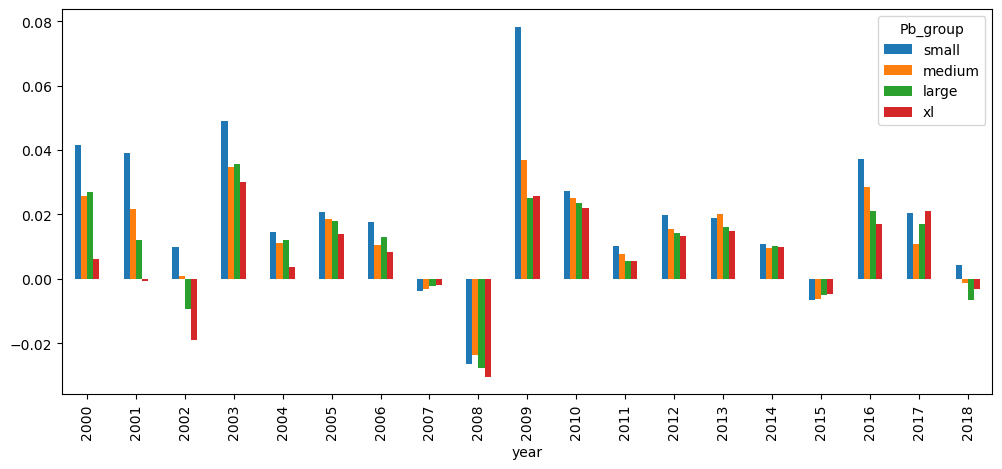

In [163]:
df_quartile.pivot(index = 'year', columns = 'Pb_group', values = 'R1M_Usd').plot.bar(figsize = (12,5))